Dengue Severity Prediction from Clinical Symptoms.      
Name: Dhruv Jain                                                                                                       
Final Working Solution (Week 12)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Dengue diseases dataset.csv")

# Preview the data
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1003 non-null   int64  
 1   Sex                 1003 non-null   object 
 2   Haemoglobin         1003 non-null   float64
 3   WBC Count           979 non-null    float64
 4   Differential Count  1003 non-null   int64  
 5   RBC PANEL           1003 non-null   int64  
 6   Platelet Count      986 non-null    float64
 7   PDW                 984 non-null    float64
 8   Final Output        989 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 70.7+ KB


In [ ]:
df['Final Output'].unique()
df['Final Output'].describe()

,Final Output
count,989.000000
mean,0.676441
std,0.468071
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- Step 1: Drop rows with missing Final Output ---
df = df.dropna(subset=['Final Output'])

# --- Step 2: Handle missing numerical values ---
# Fill missing WBC Count, Platelet Count, PDW with column mean
for col in ['WBC Count', 'Platelet Count', 'PDW']:
    df[col].fillna(df[col].mean(), inplace=True)

# --- Step 3: Encode categorical column 'Sex' ---
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
# Male → 1, Female → 0

# --- Step 4: Separate features (X) and target (y) ---
X = df.drop(['Final Output'], axis=1)
y = df['Final Output']

# --- Step 5: Standardize numerical features ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# --- Step 6: Check results ---
print("✅ Preprocessing Complete!")
print("Data shape:", X_scaled.shape)
print("\nPreview of cleaned data:")
print(X_scaled.head())

✅ Preprocessing Complete!
Data shape: (989, 8)

Preview of cleaned data:
        Age       Sex  Haemoglobin  WBC Count  Differential Count  RBC PANEL  \
0  0.038260  0.915556    -0.750284  -0.923672            0.254137   0.256384   
1  0.133815  0.915556    -0.345798  -0.578056           -3.934887   0.256384   
2  0.372700 -0.856430    -1.828916  -0.448450            0.254137   0.256384   
3  0.707140 -0.856430    -1.222186  -0.362046            0.254137  -3.900399   
4  0.420477 -0.856430    -0.480627  -0.534854           -3.934887   0.256384   

   Platelet Count       PDW  
0       -0.594499 -0.814716  
1       -1.102113 -0.402162  
2       -1.079553 -0.450293  
3       -0.966749 -0.608439  
4       -0.955469 -0.574060  


/tmp/ipython-input-1642718575.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)



🔹 Logistic Regression Results:
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        64
         1.0       1.00      1.00      1.00       134

    accuracy                           1.00       198
   macro avg       1.00      1.00      1.00       198
weighted avg       1.00      1.00      1.00       198


🔹 Random Forest Results:
Accuracy: 0.995
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        64
         1.0       1.00      0.99      1.00       134

    accuracy                           0.99       198
   macro avg       0.99      1.00      0.99       198
weighted avg       1.00      0.99      0.99       198



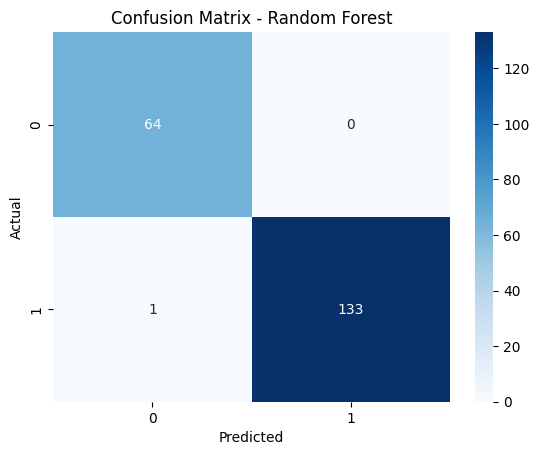

In [ ]:
# --- Step 1: Import libraries ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Step 2: Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# --- Step 3: Train multiple models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n🔹 {name} Results:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print(classification_report(y_test, y_pred))

# --- Optional Step 4: Confusion matrix for Random Forest ---
import seaborn as sns
import matplotlib.pyplot as plt

rf_pred = models["Random Forest"].predict(X_test)
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipython-input-4190133470.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


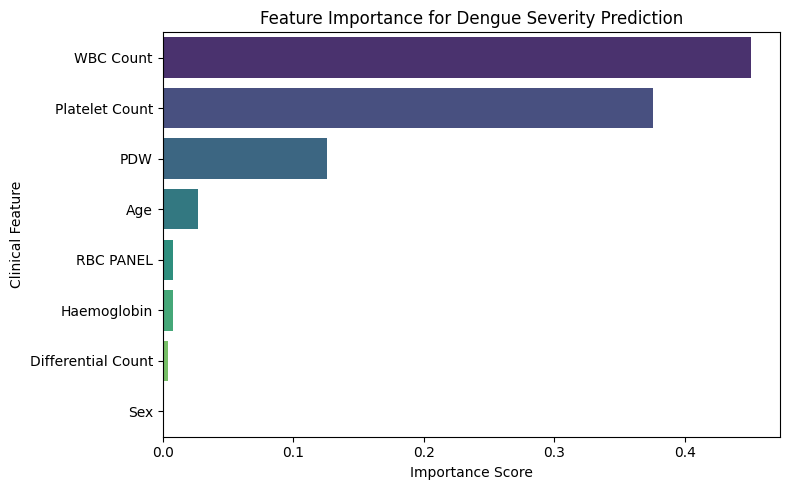

,Feature,Importance
3,WBC Count,0.450521
6,Platelet Count,0.375626
7,PDW,0.125553
0,Age,0.026985
5,RBC PANEL,0.008022
2,Haemoglobin,0.007974
4,Differential Count,0.004138
1,Sex,0.001180


In [ ]:
# --- Step 7: Feature Importance Analysis ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance values from Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

# Match them with feature names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- Plot feature importances ---
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Dengue Severity Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.show()

# Display numeric importance table
feature_importance_df